In [29]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
import sys, os, shutil
import time

current_dir = os.getcwd()
package_dir = current_dir + '/packages'
sys.path.append(package_dir)

import crydberg as rd

# Generating system

In [32]:
N = 10
n_networks = 100
n_thermalSamples = 100
n_samples = n_networks*n_thermalSamples
K = 1

# making fresh directory
dir = f'data/N{N}_K{K}'
if os.path.exists(dir): shutil.rmtree(dir)
os.makedirs(dir)

systems = rd.MagneticSystem(N, n_samples, K=K) # generating system
systems.align_m() # randomizing initial spin config. m0
systems.m = cp.broadcast_to(systems.m[0], (n_samples, N, 3)) # copying one m0 throughout all samples

# setting Js of thermal samples batches with one J
J_toSet = []
for J in systems.J[:n_networks]:
    J_toSet.append(cp.broadcast_to(J, (n_thermalSamples, N, N)))
J_toSet = cp.array(J_toSet)
J_toSet = J_toSet.reshape(n_samples, N, N)
systems.J = J_toSet
del J_toSet # deleting buffer

# Running dynamics

In [ ]:
dt = 0.1
n_burnSteps = 20000
n_steps = 100
T_vals = cp.linspace(0, 1, 11)
np.save(f'{dir}/T_vals.npy', T_vals.get())

steps = cp.arange(n_steps)

# storing initial spins
m0 = systems.m
m0 = m0.reshape(n_networks, n_thermalSamples, N, 3)
m0 = cp.broadcast_to(m0[cp.newaxis, :, :, :, :], (n_steps, n_networks, n_thermalSamples, N, 3))

# running for each temperature
for T_idx, T in enumerate(T_vals):
    # burning-in system
    for i in range(n_burnSteps):
        systems.LLG_1stepHeun(dt, alpha=1, precession=0, T=T)
        print(f'\rProgress: {100*i/n_burnSteps}%     ', end='')
    
    # storing data
    history = []
    for i in range(n_steps):
        history.append(systems.m)
        systems.LLG_1stepHeun(dt, alpha=1, precession=0, T=T)
    history = cp.array(history).reshape(n_steps, n_networks, n_thermalSamples, N, 3)
    np.save(f'{dir}/history_N{N}_K{K}_T{T_idx}.npy', history.get())
    print(f'\r{T_idx + 1}/{T_vals.size} Done.          ')

Progress: 35.335%     

# Edwards-Anderson parameter

In [27]:
EA_vals = []
for T_idx, T in enumerate(T_vals):
    history = np.load(f'{dir}/history_N{N}_K{K}_T{T_idx}.npy')
    EA = np.mean(np.mean(history, axis=2)**2, axis=(0,1,2))
    EA_vals.append(EA)
EA_vals = np.array(EA_vals)
np.save(f'{dir}/EA_N{N}_K{K}_T{T_idx}.npy', history)

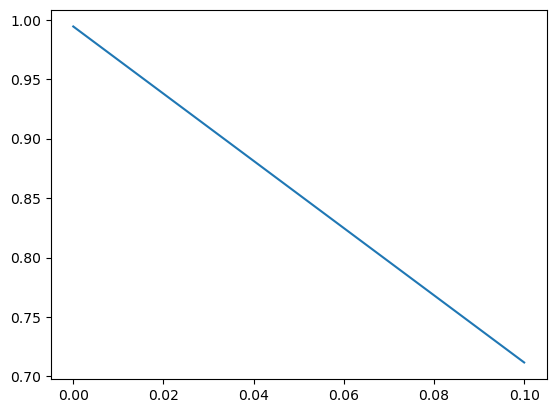

In [28]:
plt.plot(T_vals.get(), EA_vals[:,2])

In [21]:
T_vals, EA_vals[:,2]

(array([0. , 0.1]), array([0.8064    , 0.71465357]))

In [31]:
history.shape

(100, 100, 200, 10, 3)

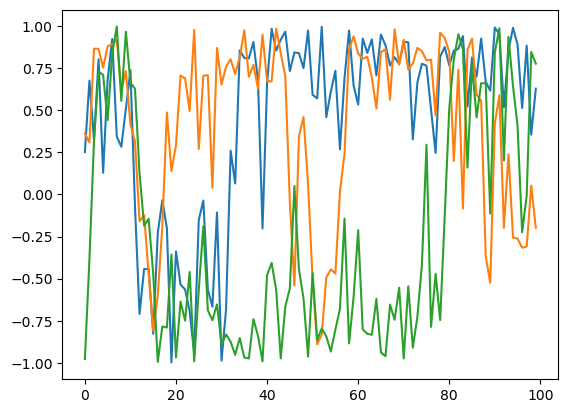

In [44]:
plt.plot(history.get()[:,0,0,7,2])
plt.plot(history.get()[:,0,1,7,2])
plt.plot(history.get()[:,0,2,7,2])

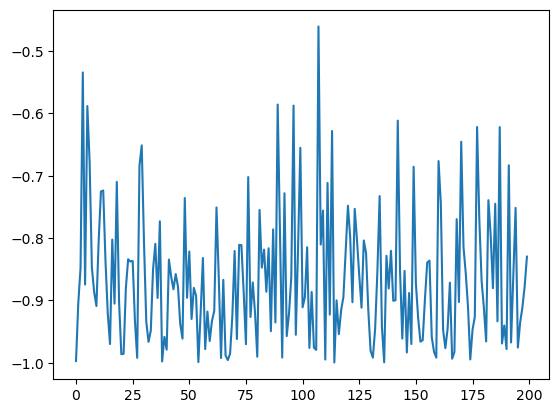

In [35]:
plt.plot(history.get()[-1,0,:,0,2])